In [1]:
import jax.numpy as jnp
import numpy as np
from matplotlib import pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns

import jax
from gstatot import utils
import os
import sys
sys.path.append('../data_preprocessing/sim/')
import sde_simulator as sde_sim

sns.set_context("paper", font_scale=1.5)
sns.set_theme(style="ticks")

In [2]:
init_seed = 0
dim = 2
save_dir = '../../data/sim_data/bistable_simulations'
os.makedirs(save_dir, exist_ok=True)
sink_rad = 0.3

time_step = 1e-2 
c = 0.01
n_iter = 10e3 

sde_sim_parameters = {
                "sigma^2": 0.1,
                "time_step": 1e-2,
                "dim": dim,
                "max_num_iter": n_iter,
                "max_pop":  2e3,
                "sample_rate": 200, 
            }

fp_n_traj_parameters = {
    'max_num_traj_itr': 1000, 
    'max_pop_buffer': 2000, 
    'num_traj_samples': 500,
}

def z0(t):
    rad = 3.0
    z = jnp.concat([
            jnp.array([rad * jnp.cos(c * t), rad * jnp.sin(c * t)]), 
            jnp.zeros((dim - 2,))
        ])
    return z 


def death(X, t):
    dr = 2.5
    return jnp.where((jnp.linalg.norm(X-z0(t)) < sink_rad), dr, 0.0)

def birth(X, t):
    gr = 5 
    a = jnp.zeros((dim,))
    A = jnp.where((jnp.linalg.norm(X-a) < 0.2), gr, 0.0)
    return A

def potential(X, t):
    return - 1* jnp.linalg.norm(X - z0(t))**2 


In [3]:
diff_coef = lambda X,t: jnp.sqrt(sde_sim_parameters["sigma^2"]) * jnp.ones( dim)

num_progenitors = 25
S = sde_sim.Simulation(potential=potential, drift=None, birth=birth, death=death, diff_coef=diff_coef,
                       sde_sim_parameters=sde_sim_parameters)

key, subkey = jax.random.split(jax.random.PRNGKey(init_seed))
X0 = jax.random.normal(subkey, shape=(num_progenitors, dim)) * 0.1
for seed in [init_seed + i for i in range(1)]:

    adata = S.make_sim_adata(seed, X0=X0, sample_traj=True, get_fp=False, **fp_n_traj_parameters)
    adata.obs['chronological_age'] = adata.obs['time'] 
    del adata.obs['time']
    adata.obs['cell_type'] = 'Progenitor'  
    X = adata.X
    for time in jnp.unique(adata.obs['chronological_age'].to_numpy()):
        mask = adata.obs['chronological_age'] == time
        sink_y_R = z0(time)
        cond_1 =  (jnp.linalg.norm(X - sink_y_R, axis=1) < sink_rad) 
        adata.obs.loc[mask & cond_1, 'cell_type'] = 'Sink'
    
        adata.obs.loc[mask, 'sink'] = (adata.obs.loc[mask, 'growth_rate'] < 0).astype(str)
        adata.obs.loc[mask, 'source'] = (adata.obs.loc[mask, 'growth_rate'] > 0).astype(str)
    adata.obsm['X_pca'] = adata.X
# exclude initial points
adata = adata[adata.obs['chronological_age'] >= 2.0].copy()
print('Number of cells at end of sim:', adata.n_obs)
print('Number of ages at end of sim:', len(np.unique(adata.obs['chronological_age'])))
print("Mean number of cells per age:", adata.n_obs / len(np.unique(adata.obs['chronological_age'])))

adata = utils.downsample_adata_by_age(adata, n=10, time_key='chronological_age')
adata.write_h5ad('./time_course_methods_comp.h5ad')

Extracting 500 trajectories starting at each of 51 time points...


100%|██████████| 51/51 [00:44<00:00,  1.15it/s]


Number of cells at end of sim: 11365
Number of ages at end of sim: 50
Mean number of cells per age: 227.3


In [4]:
adata = sc.read_h5ad('./time_course_methods_comp.h5ad')

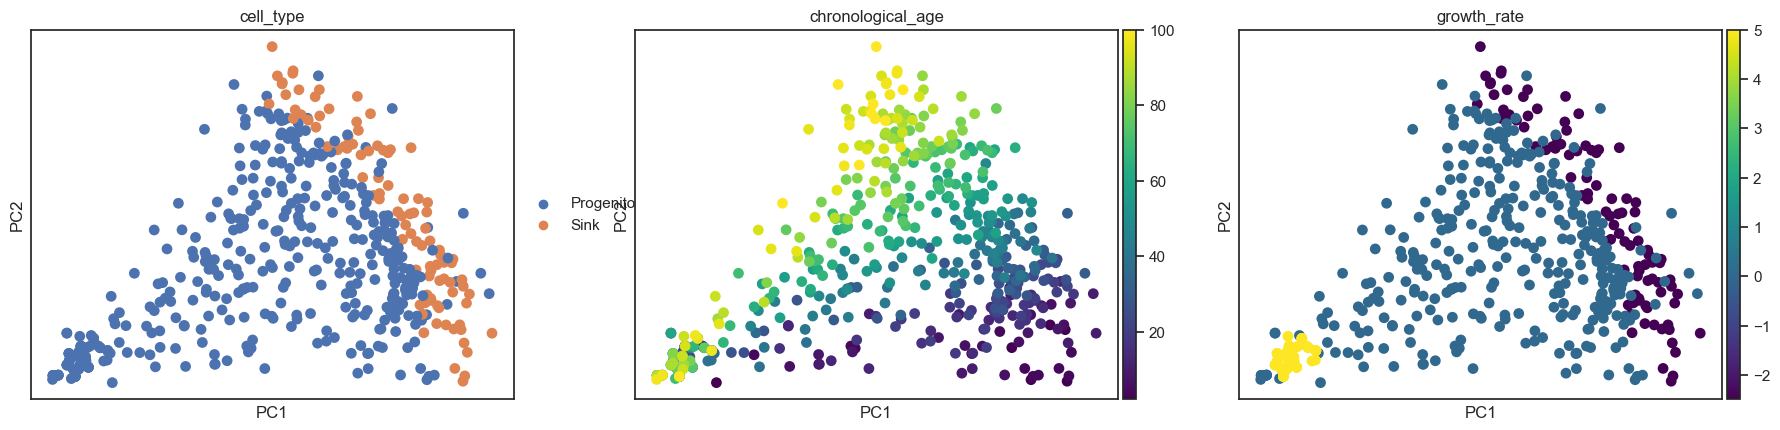

In [5]:
sc.pl.pca(adata, color=['cell_type', 'chronological_age', 'growth_rate'], cmap='viridis')

In [6]:
from gstatot import gStatOT
adata_keys = {
    'time_key': 'chronological_age',
    'growth_rate_key': 'growth_rate',
    'embed_key': 'X_pca',
}
gSOT = gStatOT(adata=adata, adata_keys=adata_keys, dt=adata.uns['true_dt'])

model_params = {'lam': 10,
                'epsilon2': 0.0025, 
                }

gSOT.fit(model_params=model_params, tol=1e-3, verbose=True)



Ran 5100 iterations in 0.22 minutes.
duality gap: 9.677e-04
max constraint error: 1.028e-04



In [7]:
lens = []
for age in gSOT.times:
    lens.extend(adata.uns['true_traj_metadata'][str(age)]['lengths'])
print(np.mean(lens))

171.89308


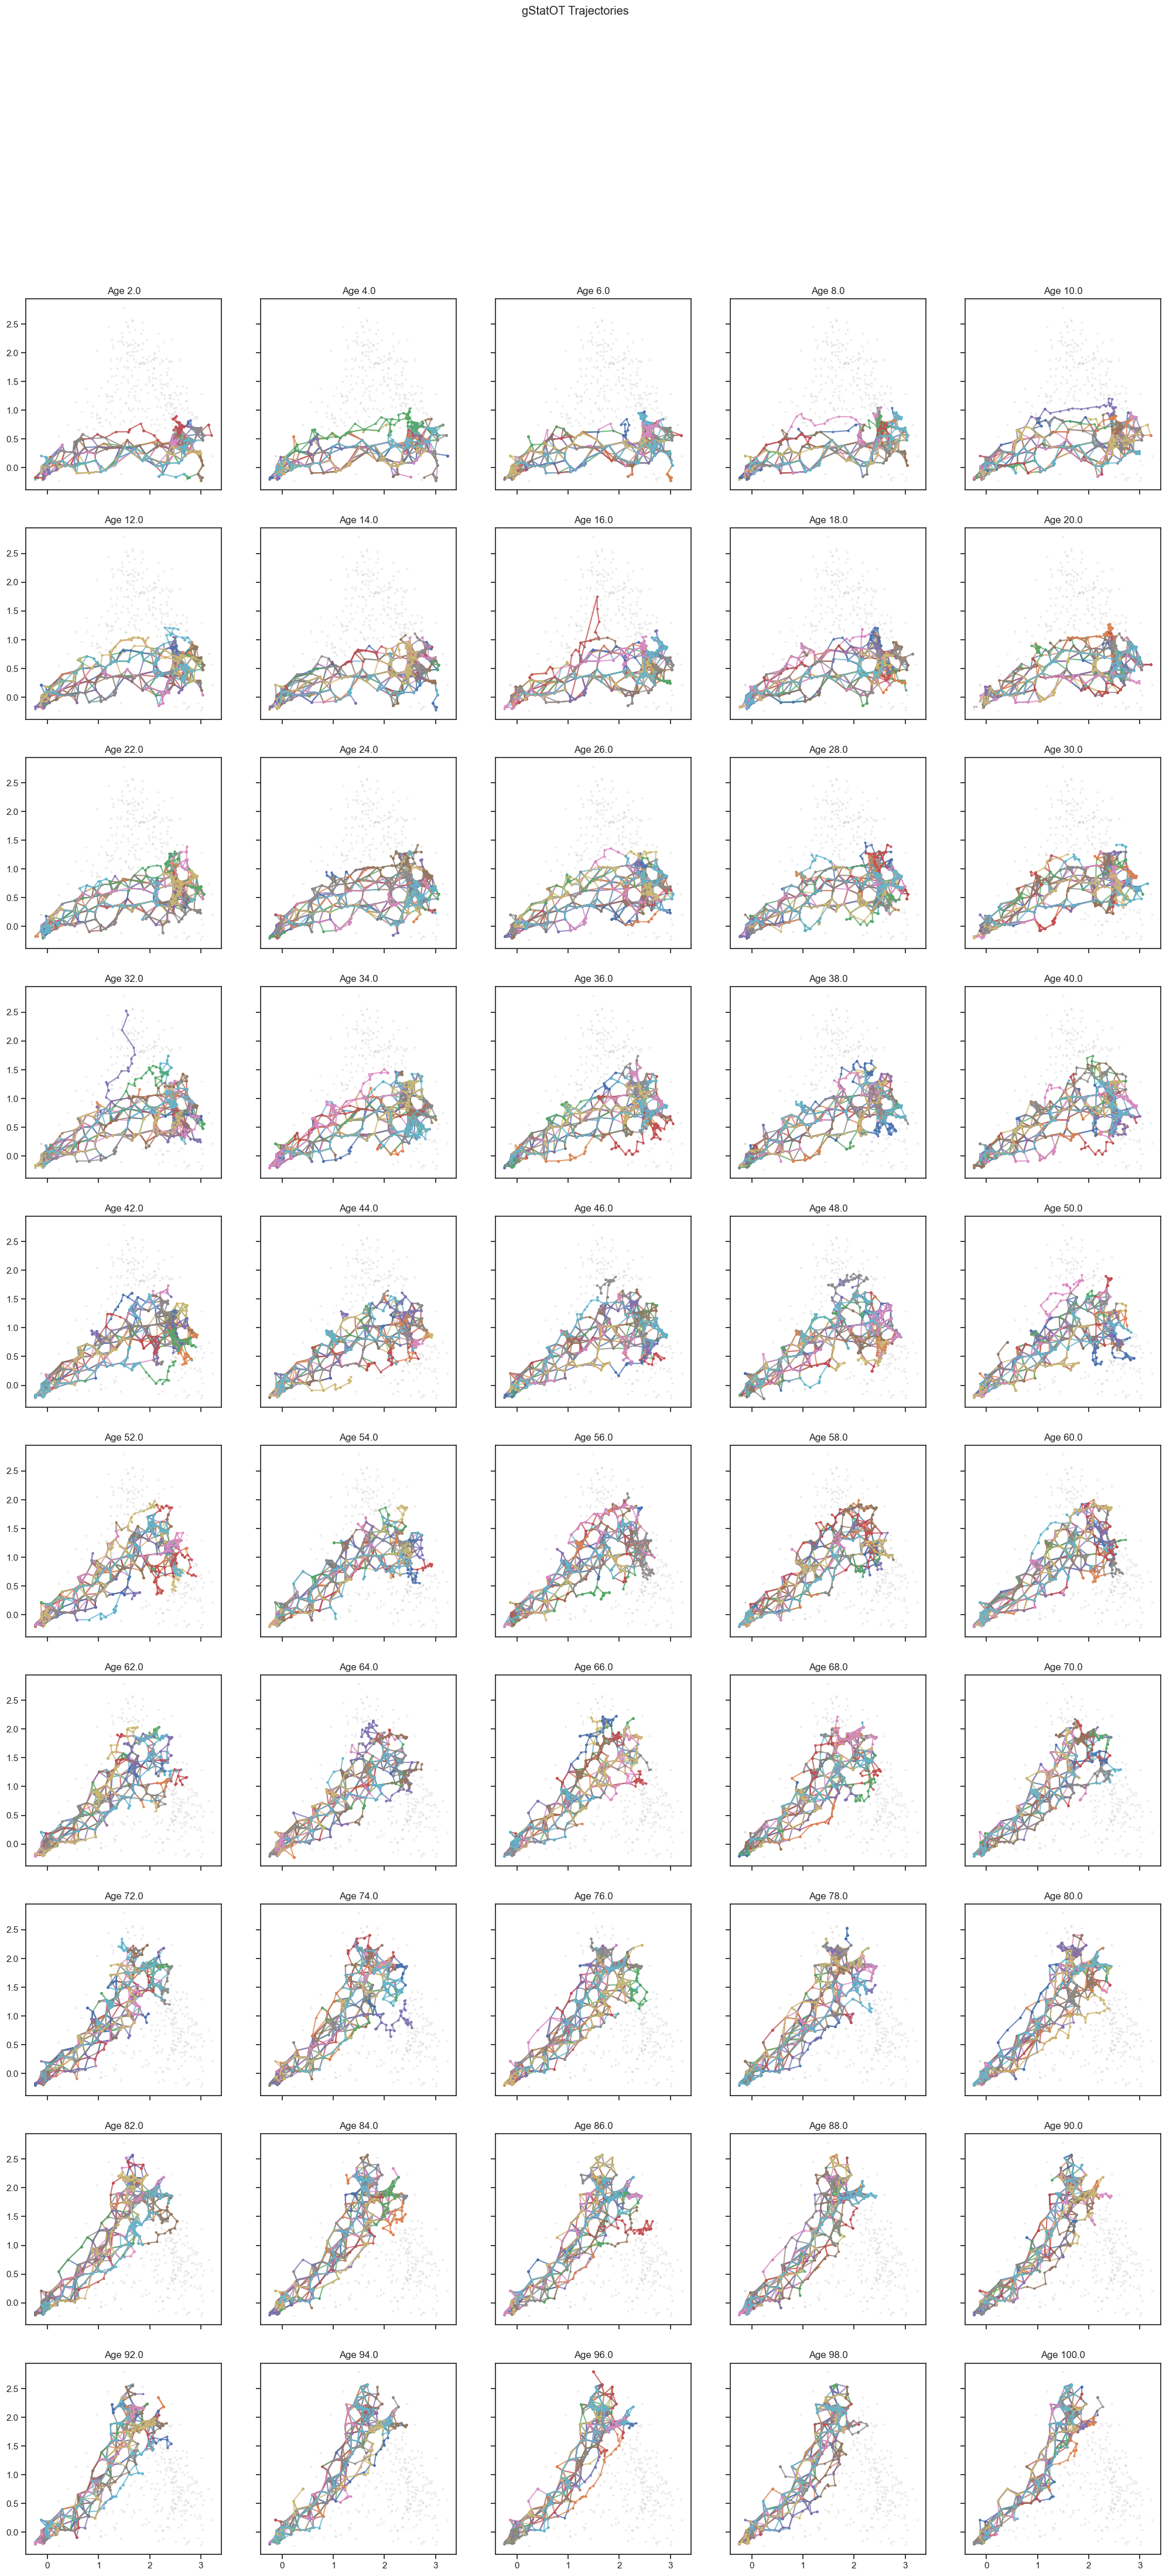

In [8]:
gSOT.get_trajectories(num_step=172, num_traj=100, plot_traj=True)

In [9]:
np.save('gSOT_traj_100', gSOT.adata.uns['gStatOT_traj_data']['100.0'], )
np.save('gSOT_traj_2', gSOT.adata.uns['gStatOT_traj_data']['2.0'], )